# Session 4 — Baseline Logistic Regression

## tl;dr

The class-balanced logistic regression baseline achieved **0.842 ROC-AUC** and **79.1% churn recall** on the untouched 1,409-customer test set. At the default 0.50 threshold it correctly identified **296 of 374 churners**, while 298 retained customers were false positives. This notebook intentionally covers only the requested baseline model and its confusion matrix.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the ChurnSense project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    build_preprocessor,
    load_telco_data,
    prepare_features_target,
    split_data,
)

DATA_PATH = PROJECT_ROOT / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
CONFUSION_MATRIX_PATH = (
    PROJECT_ROOT / "reports" / "09_baseline_logistic_confusion_matrix.png"
)
RANDOM_STATE = 42
DECISION_THRESHOLD = 0.50

sns.set_theme(style="whitegrid", context="notebook")

## Context & Methods

This experiment establishes the first Session 4 benchmark: how well a simple, interpretable linear classifier separates churners from retained customers.

### Key Assumptions

- The same deterministic, stratified 80/20 split from Session 3 is reused (`random_state=42`).
- Preprocessing and logistic regression are combined in one sklearn `Pipeline`. Imputation, scaling, and one-hot categories are fitted only on the training partition.
- `class_weight="balanced"` compensates for the 26.5% churn rate by weighting minority-class errors more heavily; no synthetic rows are created.
- Class predictions use the default probability threshold of 0.50.
- The test partition remains untouched until final baseline evaluation. No threshold tuning or model comparison is performed here.

## Data

In [2]:
raw = load_telco_data(DATA_PATH)
X, y = prepare_features_target(raw)
X_train, X_test, y_train, y_test = split_data(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "customers": [len(X_train), len(X_test)],
        "raw_features": [X_train.shape[1], X_test.shape[1]],
        "churn_rate": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)
print(f"Source: {DATA_PATH}")
display(split_summary.style.format({"churn_rate": "{:.2%}"}))

assert X_train.shape == (5634, 21)
assert X_test.shape == (1409, 21)
assert X_train.index.intersection(X_test.index).empty

Source: C:\Users\hp\Desktop\churnsense\data\WA_Fn-UseC_-Telco-Customer-Churn.csv


,customers,raw_features,churn_rate
train,5634,21,26.54%
test,1409,21,26.54%


## Results

### Fit the baseline pipeline

In [3]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_model.fit(X_train, y_train)
churn_probability = baseline_model.predict_proba(X_test)[:, 1]
y_pred = (churn_probability >= DECISION_THRESHOLD).astype("int8")

print("Baseline pipeline fitted on training data only.")
print(f"Decision threshold: {DECISION_THRESHOLD:.2f}")

Baseline pipeline fitted on training data only.
Decision threshold: 0.50


### Baseline metrics

In [4]:
baseline_metrics = pd.Series(
    {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (churn)": precision_score(y_test, y_pred),
        "Recall (churn)": recall_score(y_test, y_pred),
        "F1 (churn)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, churn_probability),
    },
    name="score",
).to_frame()

display(baseline_metrics.style.format("{:.3f}"))

,score
Accuracy,0.733
Precision (churn),0.498
Recall (churn),0.791
F1 (churn),0.612
ROC-AUC,0.842


### Confusion matrix

The matrix shows test-set customer counts. Each annotation also includes the percentage within its actual class, making the churn recall and retained-customer specificity visible without relying on color alone.

findfont: Failed to find font weight semibold, now using 700.


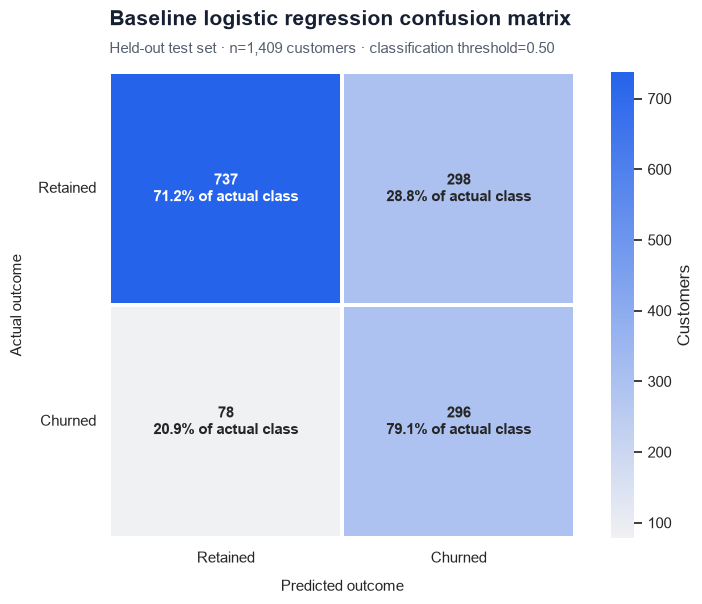

,Predicted retained,Predicted churned
Actual retained,737,298
Actual churned,78,296


Saved: C:\Users\hp\Desktop\churnsense\reports\09_baseline_logistic_confusion_matrix.png


In [5]:
matrix = confusion_matrix(y_test, y_pred)
row_percentages = matrix / matrix.sum(axis=1, keepdims=True)
annotations = np.asarray(
    [
        f"{count:,}\n{percentage:.1%} of actual class"
        for count, percentage in zip(matrix.ravel(), row_percentages.ravel())
    ]
).reshape(matrix.shape)

fig, ax = plt.subplots(figsize=(8.2, 6.2))
color_map = sns.light_palette("#2563EB", as_cmap=True)
sns.heatmap(
    matrix,
    annot=annotations,
    fmt="",
    cmap=color_map,
    cbar=True,
    cbar_kws={"label": "Customers"},
    linewidths=1.5,
    linecolor="white",
    square=True,
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"],
    annot_kws={"fontsize": 11, "fontweight": "semibold"},
    ax=ax,
)
ax.set_title(
    "Baseline logistic regression confusion matrix",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#172033",
    pad=34,
)
ax.text(
    0,
    1.035,
    "Held-out test set · n=1,409 customers · classification threshold=0.50",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#556070",
    va="bottom",
)
ax.set_xlabel("Predicted outcome", fontsize=11, labelpad=10)
ax.set_ylabel("Actual outcome", fontsize=11, labelpad=10)
ax.tick_params(axis="both", labelrotation=0)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

confusion_table = pd.DataFrame(
    matrix,
    index=["Actual retained", "Actual churned"],
    columns=["Predicted retained", "Predicted churned"],
)
display(confusion_table)
print(f"Saved: {CONFUSION_MATRIX_PATH}")

### Classification report

In [6]:
report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=["Retained", "Churned"],
        output_dict=True,
    )
).T
display(report.style.format("{:.3f}"))

,precision,recall,f1-score,support
Retained,0.904,0.712,0.797,1035.000
Churned,0.498,0.791,0.612,374.000
accuracy,0.733,0.733,0.733,0.733
macro avg,0.701,0.752,0.704,1409.000
weighted avg,0.797,0.733,0.748,1409.000


## Takeaways

- The baseline ranks churn risk well, with **ROC-AUC 0.842**.
- It catches **296 of 374 actual churners** (79.1% recall), leaving 78 false negatives.
- Churn precision is **49.8%**: 298 retained customers are also flagged, so outreach capacity and intervention cost matter when choosing a final threshold.
- Accuracy is **73.3%** and churn F1 is **0.612**. These figures are a baseline, not a final model-selection result.
- The next Session 4 step is to compare this benchmark with the remaining required algorithms under the same cross-validation and test-set protocol.